### Step-1 Import Libraries

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

### Step-2 Import Dataset

In [34]:
df = pd.read_csv('ml_data_salary.csv')
df.head()

,age,distance,YearsExperience,Salary
0,31.1,77.75,1.1,39343
1,31.3,78.25,1.3,46205
2,31.5,78.75,1.5,37731
3,32.0,80.00,2.0,43525
4,32.2,80.50,2.2,39891


In [56]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              30 non-null     float64
 1   distance         30 non-null     float64
 2   YearsExperience  30 non-null     float64
 3   Salary           30 non-null     int64  
dtypes: float64(3), int64(1)
memory usage: 1.1 KB


In [35]:
df.columns

Index(['age', 'distance', 'YearsExperience', 'Salary'], dtype='str')

array([[<Axes: title={'center': 'Salary'}>]], dtype=object)

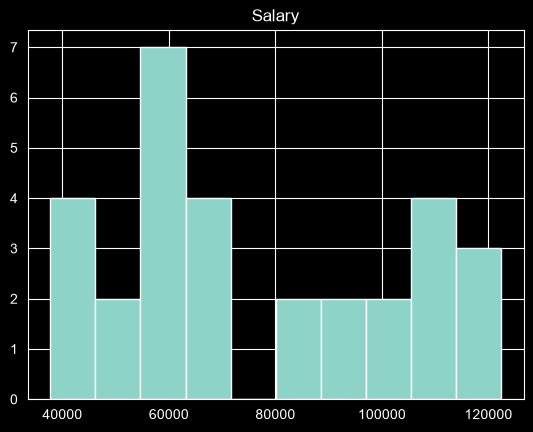

In [36]:
df.hist(['Salary'])

### Step-3 Splitting dataset into training data and testing data

In [37]:
X = df[['age', 'distance', 'YearsExperience']]
y = df['Salary']

### Create and fit the model

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

In [39]:
mlr = LinearRegression().fit(X, y)
mlr

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[1145.45,2863.62,1145.45]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['age','distance','YearsExperience']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.233e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [40]:
print('Coefficient:',mlr.coef_)

Coefficient: [1145.44997836 2863.6249459  1145.44997836]


In [41]:
print('Intercept:',mlr.intercept_)

Intercept: -223343.17009423795


In [42]:
mlr.predict([[31.1,77.75,1.1]])

array([36187.15875227])

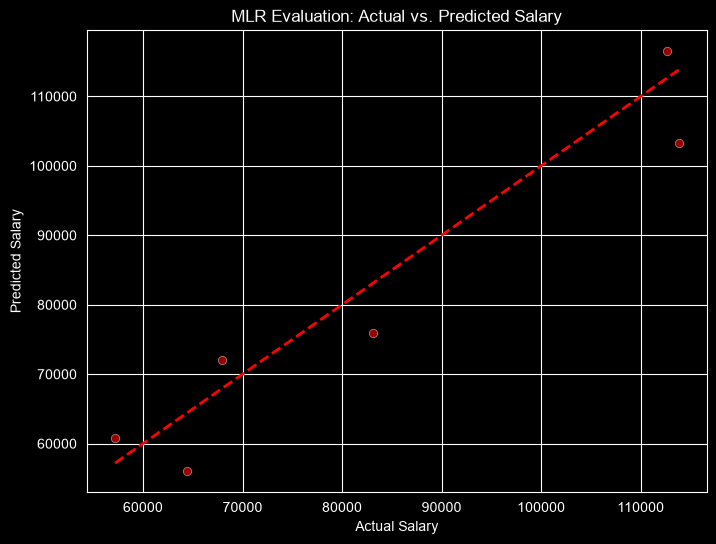

In [49]:
# 1. Generate predictions from your test data
y_pred = mlr.predict(X_test)

# 2. Plot Actual vs Predicted values
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, color='red', alpha=0.6)

# 3. Plot the perfect prediction line
perfect_line = [min(y_test), max(y_test)]
plt.plot(perfect_line, perfect_line, color='red', linestyle='--', linewidth=2)

plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.title('MLR Evaluation: Actual vs. Predicted Salary')
plt.grid(True)
plt.show()

In [45]:
# Calculate residuals
residuals = y_test - y_pred

residuals

27    -3876.838485
15    -4159.015574
23    10530.108765
17     7210.999498
8      8412.920373
9     -3568.060788
Name: Salary, dtype: float64

In [46]:
y_test.head()

27    112635
15     67938
23    113812
17     83088
8      64445
Name: Salary, dtype: int64

In [48]:
y_pred

array([116511.83848464,  72097.0155738 , 103281.8912346 ,  75877.00050238,
        56032.07962732,  60757.06078805])

In [51]:

print('Test Score =', mlr.score(X_test, y_test))
print('Train Score =', mlr.score(X_train, y_train))

Test Score = 0.9090578530656062
Train Score = 0.9640518465188769


In [54]:
# Calculate Efficacy Metrics
mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = metrics.r2_score(y_test, y_pred)

# Display Results cleanly
print("===== MODEL EFFICACY REPORT =====")
print(f"Mean Absolute Error (MAE)  : ${mae:,.2f}")
print(f"Root Mean Squared Error(RMSE): ${rmse:,.2f}")
print(f"R-squared Score (R²)       : {r2:.4f} ({r2*100:.1f}%)")

===== MODEL EFFICACY REPORT =====
Mean Absolute Error (MAE)  : $6,292.99
Root Mean Squared Error(RMSE): $6,815.63
R-squared Score (R²)       : 0.9091 (90.9%)
